# NEET-SS 2025 Result Analysis

This notebook analyzes NEET-SS 2025 ranking data to understand:
- Score and rank distributions for each specialty group
- Cutoff scores by specialty
- Statistical summaries and visualizations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11

print(" Dependencies loaded successfully!")

 Dependencies loaded successfully!


## 1. Load & Combine Excel Files

In [2]:
# Define paths to Excel files
excel_files = [
    "/Users/adityamishra/Desktop/NEET-SS_part1_pages_1-300.xlsx",
    "/Users/adityamishra/Desktop/NEET-SS_part2_pages_301-600.xlsx",
    "/Users/adityamishra/Desktop/NEET-SS_part3_pages_601-864.xlsx"
]

# Load and combine all files
dfs = []
for file in excel_files:
    if Path(file).exists():
        df_temp = pd.read_excel(file)
        dfs.append(df_temp)
        print(f"✓ Loaded: {Path(file).name} - {len(df_temp):,} rows")
    else:
        print(f"✗ File not found: {file}")

# Combine all dataframes
df_raw = pd.concat(dfs, ignore_index=True)
print(f"\nTotal records: {len(df_raw):,}")

✓ Loaded: NEET-SS_part1_pages_1-300.xlsx - 12,299 rows
✓ Loaded: NEET-SS_part2_pages_301-600.xlsx - 12,299 rows
✓ Loaded: NEET-SS_part3_pages_601-864.xlsx - 10,816 rows

Total records: 35,414


In [3]:
# Preview the data
print("Columns:")
for i, col in enumerate(df_raw.columns):
    print(f"  {i}: {repr(col)}")

print(f"\nShape: {df_raw.shape}")
display(df_raw.head(10))

Columns:
  0: 'S.No.'
  1: 'NEET-SS 2025\nQuestion Paper Group'
  2: 'Roll Number'
  3: 'Application ID'
  4: 'Total Score (Out of 600)'
  5: 'Group Specific Merit Position'

Shape: (35414, 6)


,S.No.,NEET-SS 2025\nQuestion Paper Group,Roll Number,Application ID,Total Score (Out of 600),Group Specific Merit Position
0,1.0,ANAESTHESIOLOGY GROUP,2.544101e+10,SS25000717,ABSENT,--
1,2.0,ANAESTHESIOLOGY GROUP,2.544101e+10,SS25003061,ABSENT,--
2,3.0,ANAESTHESIOLOGY GROUP,2.544101e+10,SS25003357,320,392
3,4.0,ANAESTHESIOLOGY GROUP,2.544101e+10,SS25003894,ABSENT,--
4,5.0,ANAESTHESIOLOGY GROUP,2.544101e+10,SS25005088,285,736
5,6.0,ANAESTHESIOLOGY GROUP,2.544101e+10,SS25008622,249,1055
6,7.0,ANAESTHESIOLOGY GROUP,2.544101e+10,SS25008698,255,1000
7,8.0,ANAESTHESIOLOGY GROUP,2.544101e+10,SS25008944,133,1489
8,9.0,ANAESTHESIOLOGY GROUP,2.544101e+10,SS25010104,228,1228
9,10.0,ANAESTHESIOLOGY GROUP,2.544101e+10,SS25010141,277,813


## 2. Clean & Process Data

In [4]:
# Rename columns for easier access
df = df_raw.copy()

# Clean column names (remove newlines, extra spaces)
df.columns = [col.replace('\n', ' ').strip() for col in df.columns]

# Create cleaner column names
column_mapping = {
    'S.No.': 'SNo',
    'NEET-SS 2025 Question Paper Group': 'Specialty_Group',
    'Roll Number': 'Roll_Number',
    'Application ID': 'Application_ID',
    'Total Score (Out of 600)': 'Score',
    'Group Specific Merit Position': 'Group_Rank'
}

# Apply mapping for columns that exist
df = df.rename(columns=column_mapping)

print("Renamed columns:")
print(df.columns.tolist())
display(df.head())

Renamed columns:
['SNo', 'Specialty_Group', 'Roll_Number', 'Application_ID', 'Score', 'Group_Rank']


,SNo,Specialty_Group,Roll_Number,Application_ID,Score,Group_Rank
0,1.0,ANAESTHESIOLOGY GROUP,2.544101e+10,SS25000717,ABSENT,--
1,2.0,ANAESTHESIOLOGY GROUP,2.544101e+10,SS25003061,ABSENT,--
2,3.0,ANAESTHESIOLOGY GROUP,2.544101e+10,SS25003357,320,392
3,4.0,ANAESTHESIOLOGY GROUP,2.544101e+10,SS25003894,ABSENT,--
4,5.0,ANAESTHESIOLOGY GROUP,2.544101e+10,SS25005088,285,736


In [5]:
# Convert Score to numeric (handle 'ABSENT' values)
df['Score_Numeric'] = pd.to_numeric(df['Score'], errors='coerce')

# Convert Rank to numeric (handle '--' values)
df['Rank_Numeric'] = pd.to_numeric(
    df['Group_Rank'].astype(str).str.replace('--', '').str.strip(), 
    errors='coerce'
)

# Clean specialty group names
df['Specialty'] = df['Specialty_Group'].str.strip()

# Summary
print(f"Total records: {len(df):,}")
print(f"Records with valid scores: {df['Score_Numeric'].notna().sum():,}")
print(f"Records marked ABSENT: {(df['Score'] == 'ABSENT').sum():,}")
print(f"\nScore range: {df['Score_Numeric'].min():.0f} - {df['Score_Numeric'].max():.0f}")
print(f"Rank range: {df['Rank_Numeric'].min():.0f} - {df['Rank_Numeric'].max():.0f}")

Total records: 35,414
Records with valid scores: 31,050
Records marked ABSENT: 3,499

Score range: -5 - 533
Rank range: 1 - 9722


In [6]:
# Create a filtered dataframe with only valid scores (excluding ABSENT)
df_valid = df[df['Score_Numeric'].notna()].copy()
print(f"Valid records for analysis: {len(df_valid):,}")

Valid records for analysis: 31,050


## 3. Specialty Groups Overview

In [7]:
# List all specialty groups
specialties = df_valid['Specialty'].unique()
print(f"Found {len(specialties)} specialty groups:\n")

for i, spec in enumerate(sorted(specialties), 1):
    count = len(df_valid[df_valid['Specialty'] == spec])
    print(f"{i:2}. {spec}: {count:,} candidates")

Found 15 specialty groups:

 1. ANAESTHESIOLOGY GROUP: 1,500 candidates
 2. Critical Care Medicine Group: 2,800 candidates
 3. ENT Group: 543 candidates
 4. MEDICAL GROUP: 9,722 candidates
 5. Medical Oncology Group: 1,564 candidates
 6. Microbiology Group: 92 candidates
 7. Obstetrics and Gynaecology Group: 1,238 candidates
 8. Orthopaedics Group: 265 candidates
 9. Paediatric Group: 2,685 candidates
10. Pathology Group: 588 candidates
11. Pharmacology Group: 66 candidates
12. Psychiatry Group: 66 candidates
13. Radiodiagnosis Group: 718 candidates
14. Respiratory Medicine Group: 754 candidates
15. SURGICAL GROUP: 8,449 candidates


In [8]:
# Detailed statistics by specialty
specialty_stats = df_valid.groupby('Specialty').agg({
    'Score_Numeric': ['count', 'min', 'max', 'mean', 'median', 'std'],
    'Rank_Numeric': ['min', 'max']
}).round(2)

# Flatten column names
specialty_stats.columns = ['_'.join(col).strip() for col in specialty_stats.columns]
specialty_stats = specialty_stats.rename(columns={
    'Score_Numeric_count': 'Candidates',
    'Score_Numeric_min': 'Min_Score',
    'Score_Numeric_max': 'Max_Score',
    'Score_Numeric_mean': 'Mean_Score',
    'Score_Numeric_median': 'Median_Score',
    'Score_Numeric_std': 'Std_Dev',
    'Rank_Numeric_min': 'Top_Rank',
    'Rank_Numeric_max': 'Last_Rank'
})

# Sort by mean score (most competitive first)
specialty_stats = specialty_stats.sort_values('Mean_Score', ascending=False)

print("Specialty-wise Statistics (sorted by mean score):")
display(specialty_stats)

Specialty-wise Statistics (sorted by mean score):


,Candidates,Min_Score,Max_Score,Mean_Score,Median_Score,Std_Dev,Top_Rank,Last_Rank
Specialty,,,,,,,,
Microbiology Group,92,98.0,533.0,358.09,389.5,90.00,1.0,92.0
Obstetrics and Gynaecology Group,1238,73.0,491.0,350.20,355.0,55.69,1.0,1238.0
Radiodiagnosis Group,718,78.0,485.0,348.43,356.5,67.25,1.0,718.0
Psychiatry Group,66,184.0,500.0,326.65,324.5,58.59,1.0,66.0
Respiratory Medicine Group,754,0.0,504.0,319.65,325.0,78.28,1.0,754.0
Orthopaedics Group,265,116.0,430.0,290.17,294.0,64.32,1.0,265.0
ENT Group,543,45.0,491.0,289.90,294.0,76.38,1.0,543.0
Pathology Group,588,61.0,495.0,289.35,290.0,85.61,1.0,588.0
Critical Care Medicine Group,2800,4.0,475.0,288.29,288.5,66.53,1.0,2800.0


In [9]:
# Cutoff analysis (minimum qualifying score per specialty)
cutoffs = df_valid.groupby('Specialty').agg({
    'Score_Numeric': ['min', 'max', 'median', 'count']
}).round(1)

cutoffs.columns = ['Cutoff_Score', 'Topper_Score', 'Median_Score', 'Total_Candidates']
cutoffs = cutoffs.sort_values('Cutoff_Score', ascending=False)

print("\nCutoff Scores by Specialty (sorted by competitiveness):")
display(cutoffs)


Cutoff Scores by Specialty (sorted by competitiveness):


,Cutoff_Score,Topper_Score,Median_Score,Total_Candidates
Specialty,,,,
Psychiatry Group,184.0,500.0,324.5,66
Orthopaedics Group,116.0,430.0,294.0,265
Microbiology Group,98.0,533.0,389.5,92
ANAESTHESIOLOGY GROUP,80.0,439.0,284.0,1500
Radiodiagnosis Group,78.0,485.0,356.5,718
Obstetrics and Gynaecology Group,73.0,491.0,355.0,1238
Pathology Group,61.0,495.0,290.0,588
Pharmacology Group,48.0,460.0,236.0,66
ENT Group,45.0,491.0,294.0,543


## 4. Visualizations

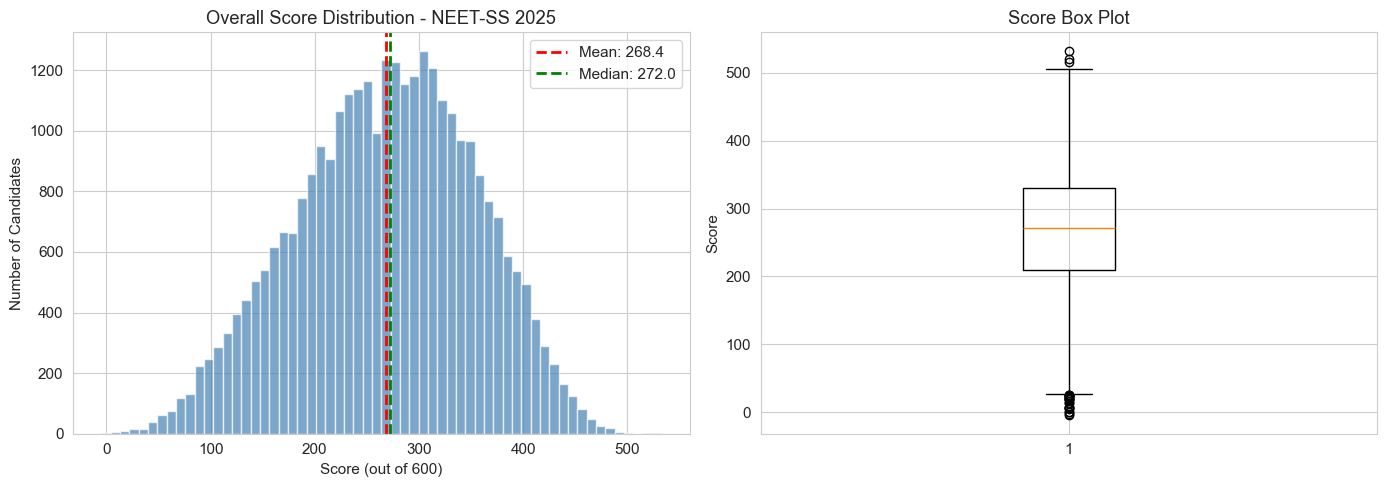


Overall Statistics:
  Total Candidates: 31,050
  Mean Score: 268.4
  Median Score: 272.0
  Std Dev: 85.8
  Min Score: -5
  Max Score: 533


In [10]:
# Overall score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_valid['Score_Numeric'], bins=60, edgecolor='white', alpha=0.7, color='steelblue')
axes[0].axvline(df_valid['Score_Numeric'].mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {df_valid["Score_Numeric"].mean():.1f}')
axes[0].axvline(df_valid['Score_Numeric'].median(), color='green', linestyle='--', linewidth=2, 
                label=f'Median: {df_valid["Score_Numeric"].median():.1f}')
axes[0].set_xlabel('Score (out of 600)')
axes[0].set_ylabel('Number of Candidates')
axes[0].set_title('Overall Score Distribution - NEET-SS 2025')
axes[0].legend()

# Box plot
axes[1].boxplot(df_valid['Score_Numeric'], vert=True)
axes[1].set_ylabel('Score')
axes[1].set_title('Score Box Plot')

plt.tight_layout()
plt.show()

# Print statistics
print(f"\nOverall Statistics:")
print(f"  Total Candidates: {len(df_valid):,}")
print(f"  Mean Score: {df_valid['Score_Numeric'].mean():.1f}")
print(f"  Median Score: {df_valid['Score_Numeric'].median():.1f}")
print(f"  Std Dev: {df_valid['Score_Numeric'].std():.1f}")
print(f"  Min Score: {df_valid['Score_Numeric'].min():.0f}")
print(f"  Max Score: {df_valid['Score_Numeric'].max():.0f}")

/var/folders/4y/cdgg2mhs3474pdf_x3256qn00000gn/T/ipykernel_84920/1601968188.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_valid, y='Specialty', x='Score_Numeric', order=order, palette='viridis')


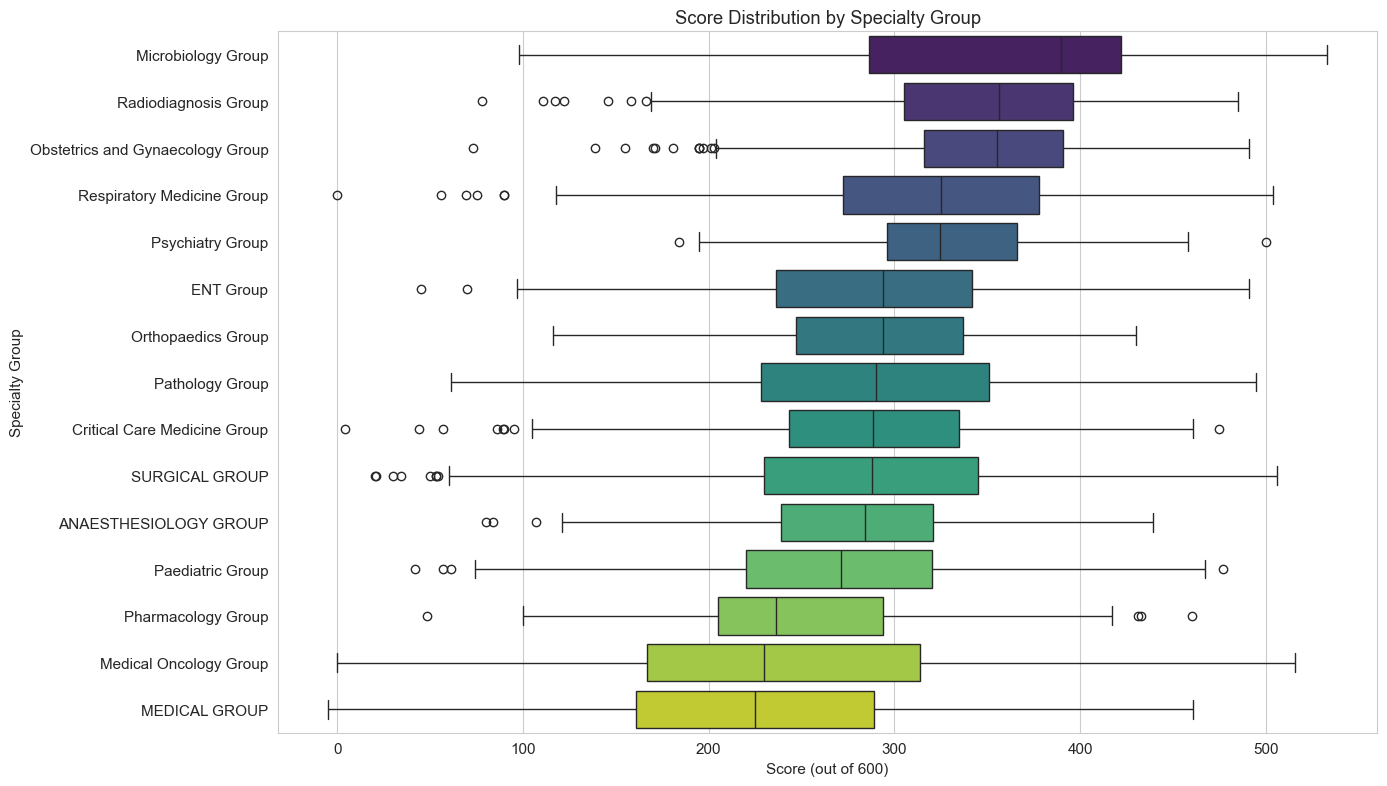

In [11]:
# Score distribution by specialty group
plt.figure(figsize=(14, 8))

# Order by median score
order = df_valid.groupby('Specialty')['Score_Numeric'].median().sort_values(ascending=False).index

sns.boxplot(data=df_valid, y='Specialty', x='Score_Numeric', order=order, palette='viridis')
plt.xlabel('Score (out of 600)')
plt.ylabel('Specialty Group')
plt.title('Score Distribution by Specialty Group')
plt.tight_layout()
plt.show()

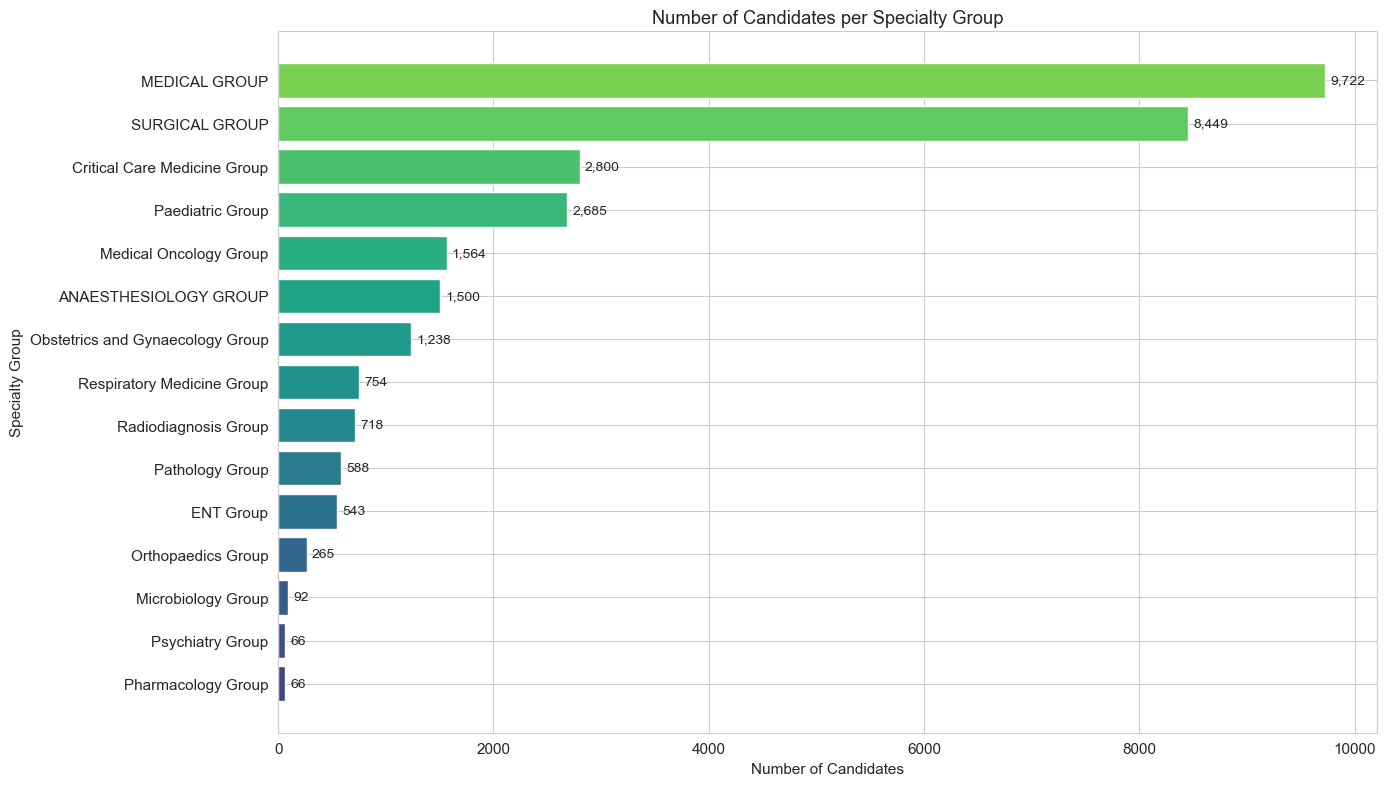

In [12]:
# Number of candidates per specialty
plt.figure(figsize=(14, 8))

spec_counts = df_valid['Specialty'].value_counts().sort_values(ascending=True)

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(spec_counts)))
bars = plt.barh(range(len(spec_counts)), spec_counts.values, color=colors)
plt.yticks(range(len(spec_counts)), spec_counts.index)
plt.xlabel('Number of Candidates')
plt.ylabel('Specialty Group')
plt.title('Number of Candidates per Specialty Group')

# Add count labels
for bar, count in zip(bars, spec_counts.values):
    plt.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2, 
             f'{count:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

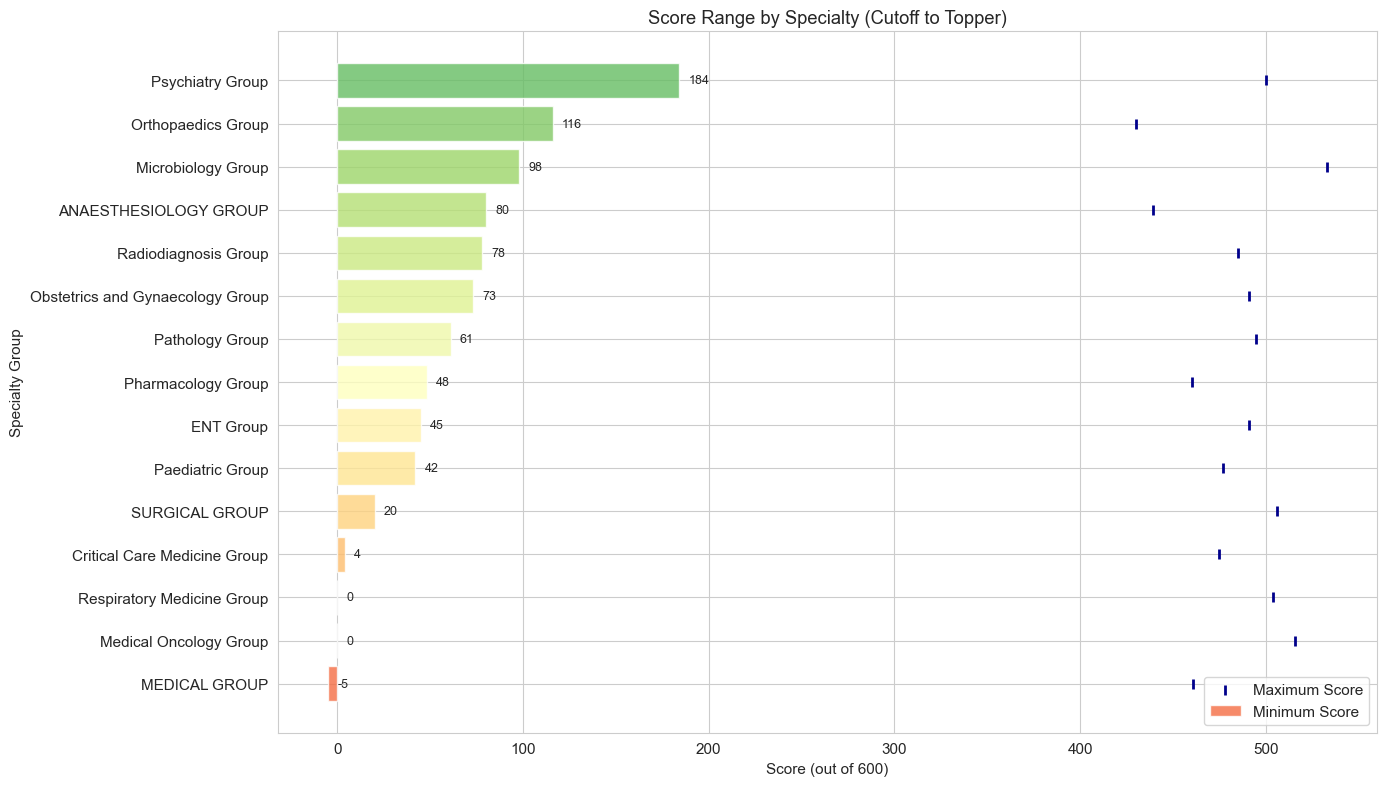

In [13]:
# Cutoff scores (minimum score) by specialty
plt.figure(figsize=(14, 8))

cutoff_data = df_valid.groupby('Specialty')['Score_Numeric'].min().sort_values(ascending=True)
max_data = df_valid.groupby('Specialty')['Score_Numeric'].max()

y_pos = range(len(cutoff_data))

# Plot min (cutoff) as bars
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(cutoff_data)))
bars = plt.barh(y_pos, cutoff_data.values, color=colors, alpha=0.8, label='Minimum Score')

# Add max score markers
plt.scatter(max_data[cutoff_data.index].values, y_pos, color='darkblue', 
            s=50, marker='|', linewidths=2, label='Maximum Score', zorder=5)

plt.yticks(y_pos, cutoff_data.index)
plt.xlabel('Score (out of 600)')
plt.ylabel('Specialty Group')
plt.title('Score Range by Specialty (Cutoff to Topper)')
plt.legend(loc='lower right')

# Add cutoff labels
for i, (bar, score) in enumerate(zip(bars, cutoff_data.values)):
    plt.text(score + 5, bar.get_y() + bar.get_height()/2, 
             f'{score:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

/var/folders/4y/cdgg2mhs3474pdf_x3256qn00000gn/T/ipykernel_84920/1294163447.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_valid, y='Specialty', x='Score_Numeric', order=order,


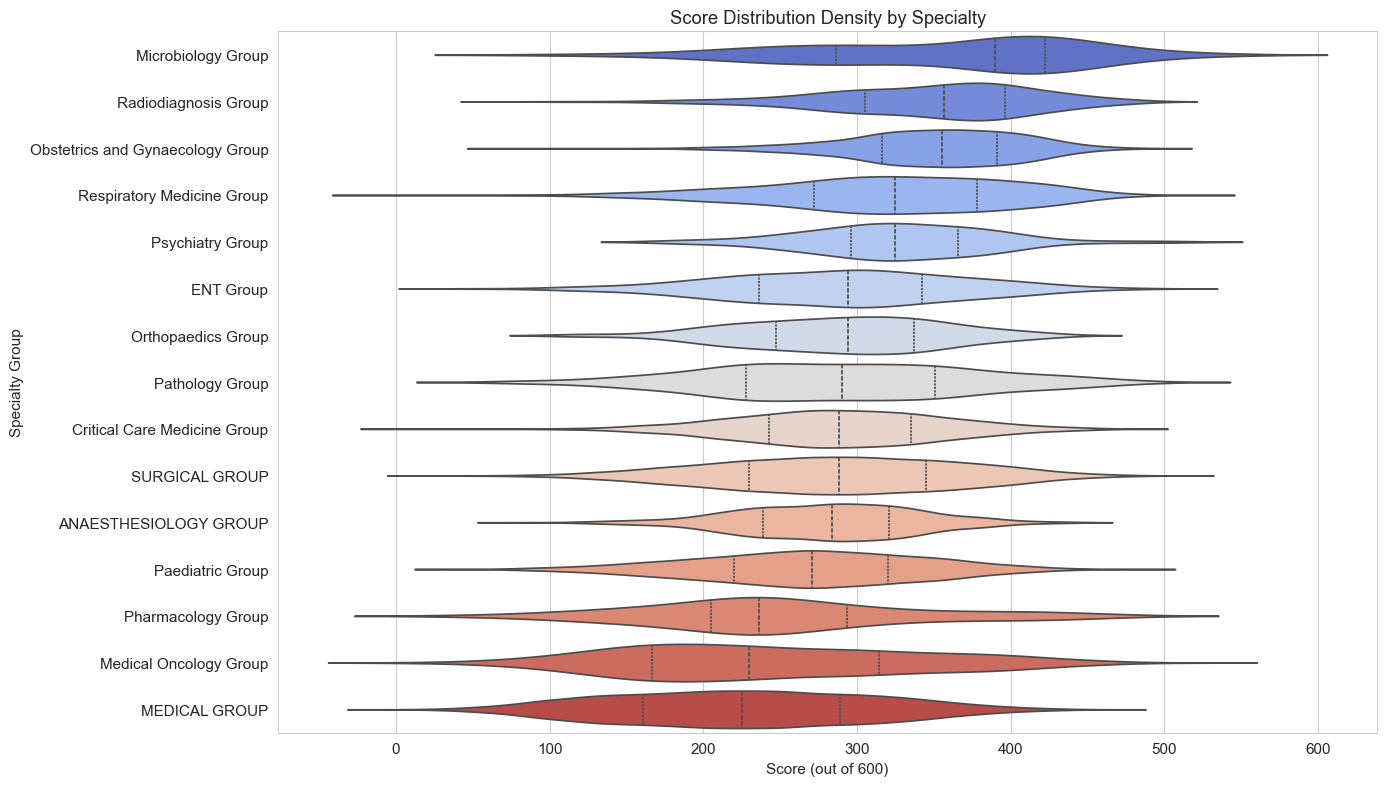

In [14]:
# Violin plot for detailed distribution comparison
plt.figure(figsize=(14, 8))

order = df_valid.groupby('Specialty')['Score_Numeric'].median().sort_values(ascending=False).index

sns.violinplot(data=df_valid, y='Specialty', x='Score_Numeric', order=order, 
               palette='coolwarm', inner='quartile')
plt.xlabel('Score (out of 600)')
plt.ylabel('Specialty Group')
plt.title('Score Distribution Density by Specialty')
plt.tight_layout()
plt.show()

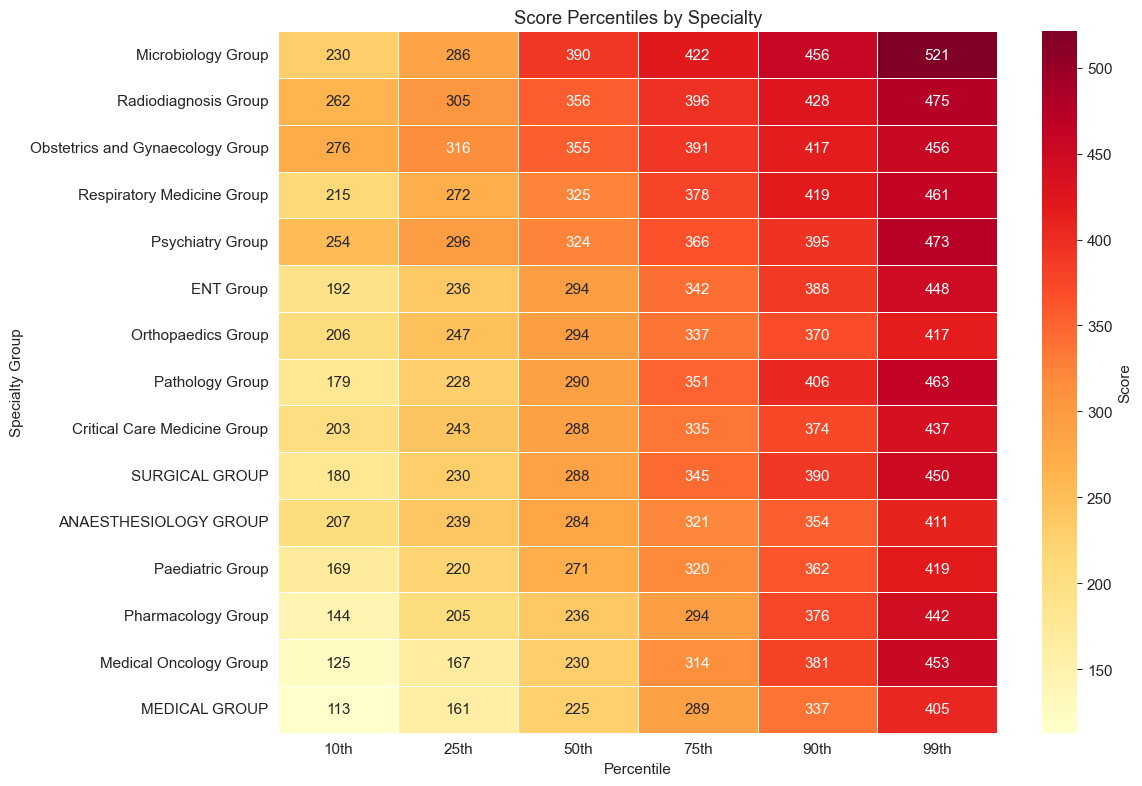


Percentile Table:


,10th,25th,50th,75th,90th,99th
Microbiology Group,230.3,286.50,389.5,422.25,456.0,521.17
Radiodiagnosis Group,262.4,305.00,356.5,396.00,427.9,474.66
Obstetrics and Gynaecology Group,276.0,316.00,355.0,391.00,417.3,455.63
Respiratory Medicine Group,214.6,272.25,325.0,377.75,418.7,461.41
Psychiatry Group,253.5,295.75,324.5,365.75,395.0,472.70
ENT Group,192.0,236.00,294.0,342.00,388.0,448.32
Orthopaedics Group,206.0,247.00,294.0,337.00,370.2,417.44
Pathology Group,179.0,228.00,290.0,351.00,406.3,463.26
Critical Care Medicine Group,203.0,243.00,288.5,335.00,374.0,437.00
SURGICAL GROUP,180.0,230.00,288.0,345.00,390.0,450.00


In [15]:
# Score percentiles heatmap
percentiles = [10, 25, 50, 75, 90, 99]
percentile_data = {}

for spec in df_valid['Specialty'].unique():
    scores = df_valid[df_valid['Specialty'] == spec]['Score_Numeric']
    percentile_data[spec] = [np.percentile(scores, p) for p in percentiles]

df_percentiles = pd.DataFrame(percentile_data, index=[f'{p}th' for p in percentiles]).T
df_percentiles = df_percentiles.sort_values('50th', ascending=False)

plt.figure(figsize=(12, 8))
sns.heatmap(df_percentiles, annot=True, fmt='.0f', cmap='YlOrRd', 
            cbar_kws={'label': 'Score'}, linewidths=0.5)
plt.xlabel('Percentile')
plt.ylabel('Specialty Group')
plt.title('Score Percentiles by Specialty')
plt.tight_layout()
plt.show()

print("\nPercentile Table:")
display(df_percentiles)

## 5. Comparative Analysis

In [16]:
# Competition index by specialty
# Higher index = more competitive (higher scores needed)

competition = df_valid.groupby('Specialty').agg({
    'Score_Numeric': ['mean', 'min', 'count']
})
competition.columns = ['Mean_Score', 'Cutoff', 'Candidates']

# Normalize and create competition index
competition['Normalized_Mean'] = (competition['Mean_Score'] - competition['Mean_Score'].min()) / \
                                  (competition['Mean_Score'].max() - competition['Mean_Score'].min())
competition['Normalized_Cutoff'] = (competition['Cutoff'] - competition['Cutoff'].min()) / \
                                    (competition['Cutoff'].max() - competition['Cutoff'].min())

# Competition index (weighted average)
competition['Competition_Index'] = (competition['Normalized_Mean'] * 0.6 + competition['Normalized_Cutoff'] * 0.4) * 100
competition = competition.sort_values('Competition_Index', ascending=False)

print("Competition Index by Specialty (higher = more competitive):")
display(competition[['Mean_Score', 'Cutoff', 'Candidates', 'Competition_Index']].round(1))

Competition Index by Specialty (higher = more competitive):


,Mean_Score,Cutoff,Candidates,Competition_Index
Specialty,,,,
Psychiatry Group,326.7,184.0,66,85.8
Microbiology Group,358.1,98.0,92,81.8
Radiodiagnosis Group,348.4,78.0,718,73.2
Obstetrics and Gynaecology Group,350.2,73.0,1238,72.9
Orthopaedics Group,290.2,116.0,265,54.9
Respiratory Medicine Group,319.7,0.0,754,43.7
ANAESTHESIOLOGY GROUP,281.0,80.0,1500,43.2
Pathology Group,289.4,61.0,588,42.9
ENT Group,289.9,45.0,543,39.8


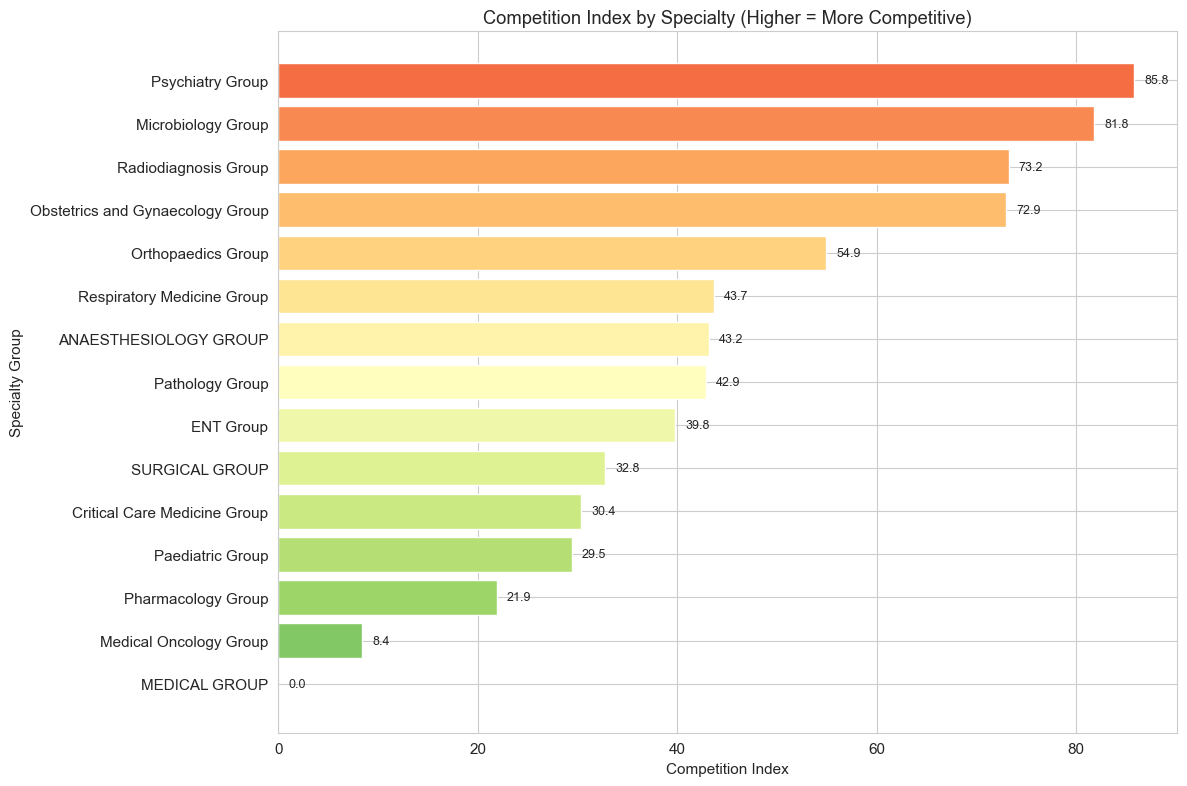

In [17]:
# Visualize competition index
plt.figure(figsize=(12, 8))

comp_sorted = competition.sort_values('Competition_Index', ascending=True)
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(comp_sorted)))

bars = plt.barh(range(len(comp_sorted)), comp_sorted['Competition_Index'].values, color=colors)
plt.yticks(range(len(comp_sorted)), comp_sorted.index)
plt.xlabel('Competition Index')
plt.ylabel('Specialty Group')
plt.title('Competition Index by Specialty (Higher = More Competitive)')

for bar, val in zip(bars, comp_sorted['Competition_Index'].values):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
             f'{val:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Interactive Analysis Functions

In [19]:
def analyze_specialty(specialty_name):
    """
    Get detailed analysis for a specific specialty.
    Use partial name matching (case-insensitive).
    """
    spec_data = df_valid[df_valid['Specialty'].str.contains(specialty_name, case=False, na=False)]
    
    if len(spec_data) == 0:
        print(f"No data found for: {specialty_name}")
        print(f"\nAvailable specialties: {df_valid['Specialty'].unique().tolist()}")
        return
    
    specialty = spec_data['Specialty'].iloc[0]
    scores = spec_data['Score_Numeric']
    
    print(f"\n{'='*60}")
    print(f"Analysis for: {specialty}")
    print(f"{'='*60}")
    print(f"\nTotal Candidates: {len(spec_data):,}")
    print(f"\nScore Statistics:")
    print(f"  Min (Cutoff): {scores.min():.0f}")
    print(f"  Max (Topper): {scores.max():.0f}")
    print(f"  Mean: {scores.mean():.1f}")
    print(f"  Median: {scores.median():.1f}")
    print(f"  Std Dev: {scores.std():.1f}")
    
    print(f"\nPercentiles:")
    for p in [10, 25, 50, 75, 90, 95, 99]:
        print(f"  {p}th percentile: {np.percentile(scores, p):.0f}")
    
    # Quick histogram
    plt.figure(figsize=(10, 4))
    plt.hist(scores, bins=30, edgecolor='white', alpha=0.7, color='steelblue')
    plt.axvline(scores.mean(), color='red', linestyle='--', label=f'Mean: {scores.mean():.1f}')
    plt.axvline(scores.median(), color='green', linestyle='--', label=f'Median: {scores.median():.1f}')
    plt.xlabel('Score')
    plt.ylabel('Candidates')
    plt.title(f'Score Distribution - {specialty}')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return spec_data


def find_rank_for_score(score, specialty_name=None):
    """
    Find approximate rank for a given score.
    If specialty_name is provided, find rank within that specialty.
    """
    if specialty_name:
        data = df_valid[df_valid['Specialty'].str.contains(specialty_name, case=False, na=False)]
        context = f"in {data['Specialty'].iloc[0]}" if len(data) > 0 else ""
    else:
        data = df_valid
        context = "overall"
    
    if len(data) == 0:
        print("No matching data found.")
        return
    
    scores = data['Score_Numeric'].dropna().sort_values(ascending=False)
    rank = (scores >= score).sum()
    percentile = (scores < score).sum() / len(scores) * 100
    
    print(f"\nScore: {score} ({context})")
    print(f"Approximate Rank: {rank:,} out of {len(scores):,}")
    print(f"Percentile: {percentile:.1f}% (better than {percentile:.1f}% candidates)")
    print(f"Top {100-percentile:.1f}%")


def compare_specialties(*specialty_names):
    """
    Compare multiple specialties side by side.
    """
    comparison = []
    for name in specialty_names:
        data = df_valid[df_valid['Specialty'].str.contains(name, case=False, na=False)]
        if len(data) > 0:
            specialty = data['Specialty'].iloc[0]
            scores = data['Score_Numeric']
            comparison.append({
                'Specialty': specialty,
                'Candidates': len(data),
                'Min': scores.min(),
                'Max': scores.max(),
                'Mean': scores.mean(),
                'Median': scores.median()
            })
    
    df_compare = pd.DataFrame(comparison)
    print("\nComparison:")
    display(df_compare.round(1))
    
    # Visualization
    fig, ax = plt.subplots(figsize=(10, 5))
    x = range(len(df_compare))
    width = 0.35
    
    ax.bar([i - width/2 for i in x], df_compare['Mean'], width, label='Mean', color='steelblue')
    ax.bar([i + width/2 for i in x], df_compare['Median'], width, label='Median', color='coral')
    
    ax.set_xlabel('Specialty')
    ax.set_ylabel('Score')
    ax.set_title('Specialty Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels([s[:20] + '...' if len(s) > 20 else s for s in df_compare['Specialty']], rotation=45, ha='right')
    ax.legend()
    
    plt.tight_layout()
    plt.show()


print("\nHelper functions defined:")
print("  • analyze_specialty('cardiology') - Detailed stats for a specialty")
print("  • find_rank_for_score(450, 'surgery') - Find rank for a score")
print("  • compare_specialties('surgery', 'medicine') - Compare specialties")


Helper functions defined:
  • analyze_specialty('cardiology') - Detailed stats for a specialty
  • find_rank_for_score(450, 'surgery') - Find rank for a score
  • compare_specialties('surgery', 'medicine') - Compare specialties



Analysis for: Obstetrics and Gynaecology Group

Total Candidates: 1,238

Score Statistics:
  Min (Cutoff): 73
  Max (Topper): 491
  Mean: 350.2
  Median: 355.0
  Std Dev: 55.7

Percentiles:
  10th percentile: 276
  25th percentile: 316
  50th percentile: 355
  75th percentile: 391
  90th percentile: 417
  95th percentile: 430
  99th percentile: 456


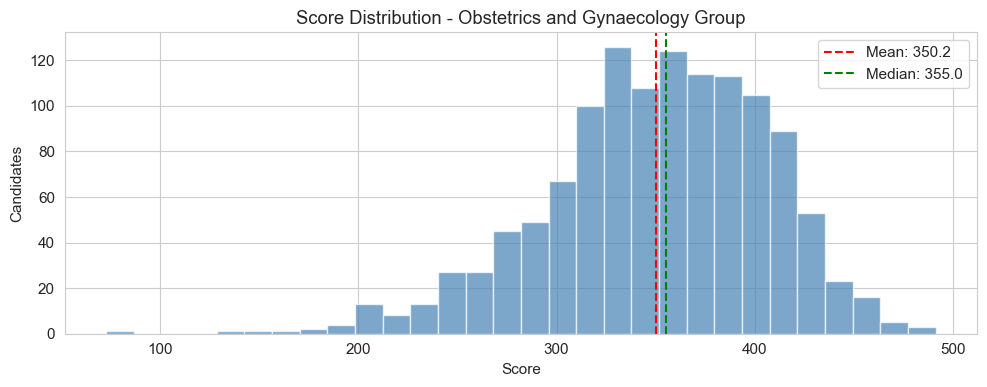

,SNo,Specialty_Group,Roll_Number,Application_ID,Score,Group_Rank,Score_Numeric,Rank_Numeric,Specialty
18726,18272.0,Obstetrics and Gynaecology Group,2.544100e+10,SS25000937,427,78,427.0,78.0,Obstetrics and Gynaecology Group
18727,18273.0,Obstetrics and Gynaecology Group,2.544100e+10,SS25001719,406,198,406.0,198.0,Obstetrics and Gynaecology Group
18728,18274.0,Obstetrics and Gynaecology Group,2.544100e+10,SS25002281,338,752,338.0,752.0,Obstetrics and Gynaecology Group
18729,18275.0,Obstetrics and Gynaecology Group,2.544100e+10,SS25003730,364,532,364.0,532.0,Obstetrics and Gynaecology Group
18730,18276.0,Obstetrics and Gynaecology Group,2.544100e+10,SS25004808,409,177,409.0,177.0,Obstetrics and Gynaecology Group
...,...,...,...,...,...,...,...,...,...
20217,19726.0,Obstetrics and Gynaecology Group,2.544400e+10,SS25004159,310,964,310.0,964.0,Obstetrics and Gynaecology Group
20218,19727.0,Obstetrics and Gynaecology Group,2.544400e+10,SS25008676,273,1126,273.0,1126.0,Obstetrics and Gynaecology Group
20219,19728.0,Obstetrics and Gynaecology Group,2.544400e+10,SS25019405,230,1205,230.0,1205.0,Obstetrics and Gynaecology Group
20220,19729.0,Obstetrics and Gynaecology Group,2.544400e+10,SS25021582,333,787,333.0,787.0,Obstetrics and Gynaecology Group


In [21]:
analyze_specialty('Obstetrics and Gynaecology Group')


Comparison:


,Specialty,Candidates,Min,Max,Mean,Median
0,Critical Care Medicine Group,3554,0.0,504.0,294.9,295.5
1,Obstetrics and Gynaecology Group,1238,73.0,491.0,350.2,355.0


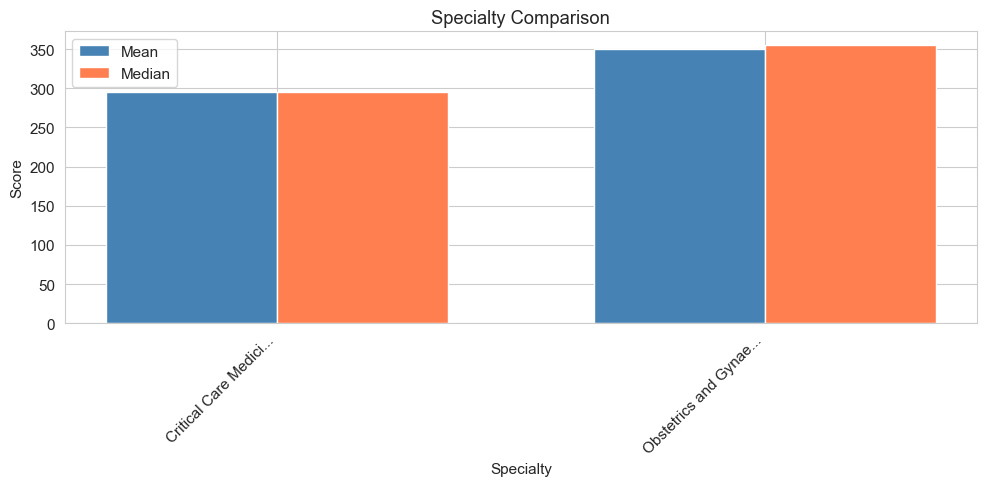

In [23]:
compare_specialties('MEDICINE', 'Obstetrics and Gynaecology Group')

## 7. Export Results

In [24]:
# Export cleaned data and analysis results
output_dir = Path('/Users/adityamishra/Desktop')

# Export cleaned combined data
df_valid.to_csv(output_dir / 'neet_ss_2025_cleaned.csv', index=False)
print(f"✓ Cleaned data: {output_dir / 'neet_ss_2025_cleaned.csv'}")

# Export specialty statistics
specialty_stats.to_csv(output_dir / 'neet_ss_2025_specialty_stats.csv')
print(f"✓ Specialty stats: {output_dir / 'neet_ss_2025_specialty_stats.csv'}")

# Export percentile data
df_percentiles.to_csv(output_dir / 'neet_ss_2025_percentiles.csv')
print(f"✓ Percentiles: {output_dir / 'neet_ss_2025_percentiles.csv'}")

print("\n✓ All exports complete!")

✓ Cleaned data: /Users/adityamishra/Desktop/neet_ss_2025_cleaned.csv
✓ Specialty stats: /Users/adityamishra/Desktop/neet_ss_2025_specialty_stats.csv
✓ Percentiles: /Users/adityamishra/Desktop/neet_ss_2025_percentiles.csv

✓ All exports complete!
